# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
!pip install seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

C:\Users\viver\AppData\Local\Temp\ipykernel_18384\3491749900.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd



---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [3]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

In [4]:
rent_by_month = df["count"].resample("MS").agg(["mean"])
rent_by_month

,mean
datetime,
2011-01-01,54.645012
2011-02-01,73.641256
2011-03-01,86.849776
2011-04-01,111.026374
2011-05-01,174.809211
2011-06-01,196.877193
2011-07-01,203.614035
2011-08-01,182.666667
2011-09-01,174.622517


In [5]:
df.head(0)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour,month_year
datetime,,,,,,,,,,,,,,,,,,,,


c:\Users\viver\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\viver\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


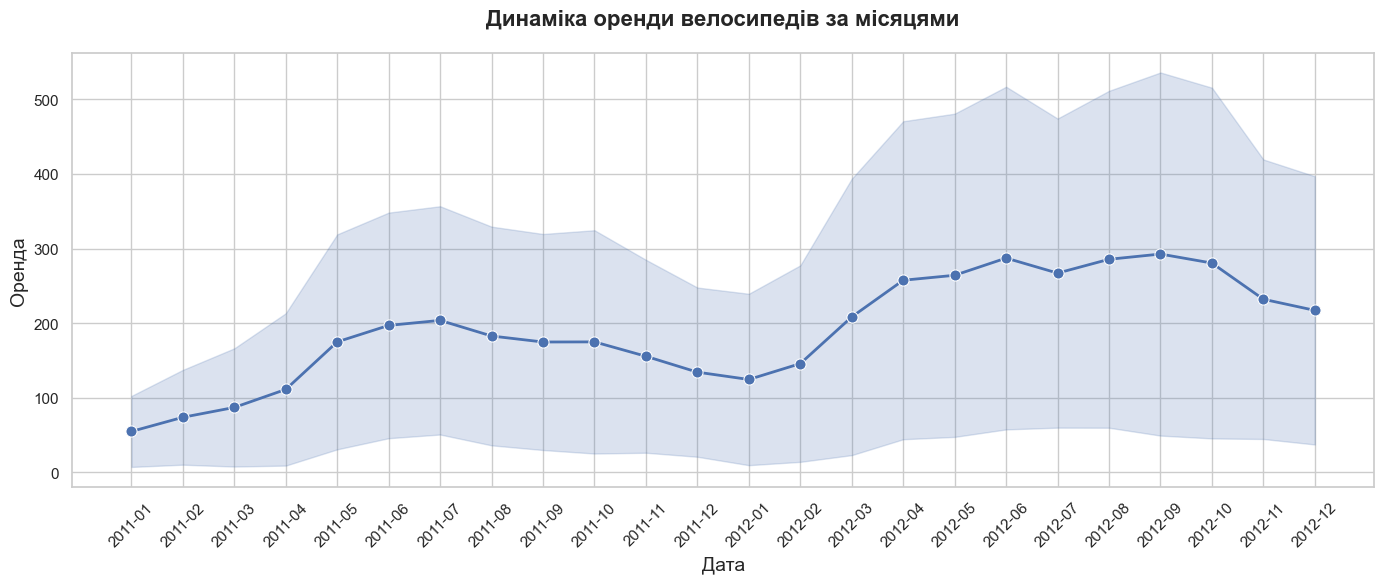

In [6]:
plt.figure(figsize=(14, 6))
sns.lineplot(df, x="month_year", y="count", errorbar="sd", marker="o", markersize=8, linewidth=2)
plt.title("Динаміка оренди велосипедів за місяцями", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Дата", fontsize=14,)
plt.ylabel("Оренда", fontsize=14,)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("mean_rent_by_month.png", dpi=300, bbox_inches="tight")
plt.show()

В які місяці найбільша невизначеність в даних?
Ширина зафарбованої зони вказує на розкид в кожному місяці, тож чим вужча ця зона - тим стабільший місяць, а там де широко - там більша невизначеність. Виходить, що червні та вересні-жовтні 2012 маємо найбільшу варіативність значень.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

c:\Users\viver\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


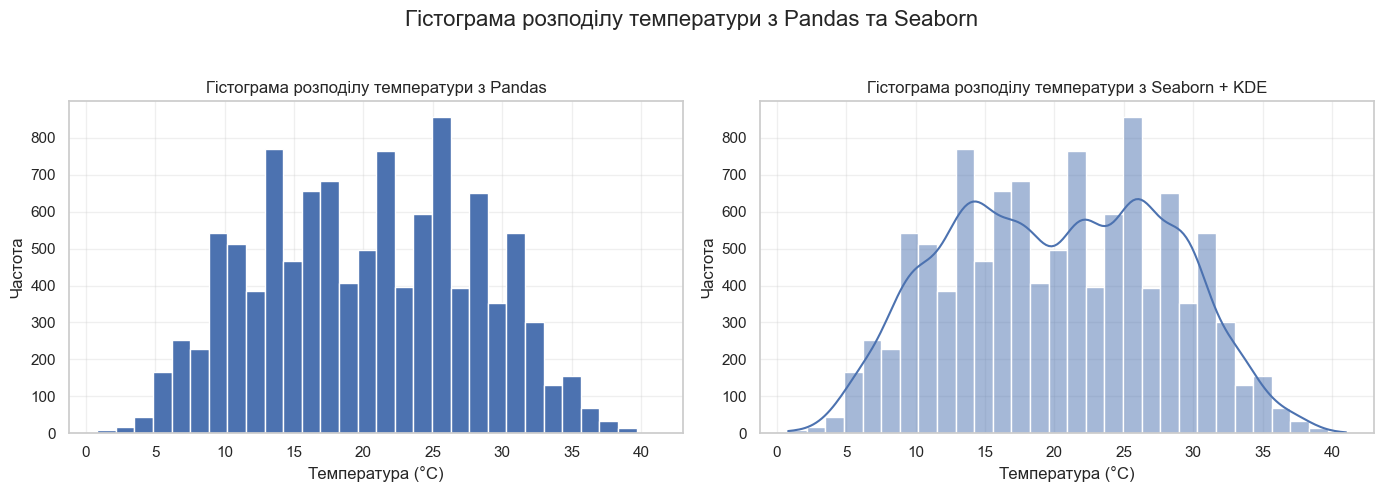

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1 - Pandas histogram
df["temp"].plot(kind="hist", bins=30, ax=ax[0])

ax[0].set_title("Гістограма розподілу температури з Pandas")
ax[0].set_xlabel("Температура (°C)")
ax[0].set_ylabel("Частота")
ax[0].grid(True, alpha=0.3)

# 2 - Seaborn histogram
sns.histplot(data=df, x="temp", bins=30, kde=True, ax=ax[1])

ax[1].set_title("Гістограма розподілу температури з Seaborn + KDE")
ax[1].set_xlabel("Температура (°C)")
ax[1].set_ylabel("Частота")
ax[1].grid(True, alpha=0.3)

# Заголовок всієї сітки
fig.suptitle("Гістограма розподілу температури з Pandas та Seaborn", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("hist_pandas_vs_seaborn.png", dpi=300, bbox_inches="tight")
plt.show()

Яка візуальна різниця між Pandas та Seaborn гістограмами?
Гістограм Pandas виглядає стандартною, базовою, натомість Seaborn ніби більш пропрацбована - прозорість стовпців, додаткова лінія KDE. Це виглядає цікавіше та інформативніше.

Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?
це і є KDE — оцінка щільності розподілу. Вона ніби згладжує нашу гістограму і показує тенденцію розподілу без різких стрибків.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

In [8]:
weather_labels = {
    1: "Ясно",
    2: "Туман",
    3: "Легкий дощ",
    4: "Сильний дощ"
}

In [9]:
df["weather_name"] = df["weather"].map(weather_labels)

In [10]:
weather_order = ["Ясно", "Туман", "Легкий дощ", "Сильний дощ"]

df["weather_name"] = pd.Categorical(
    df["weather_name"],
    categories=weather_order,
    ordered=True
)

c:\Users\viver\anaconda3\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


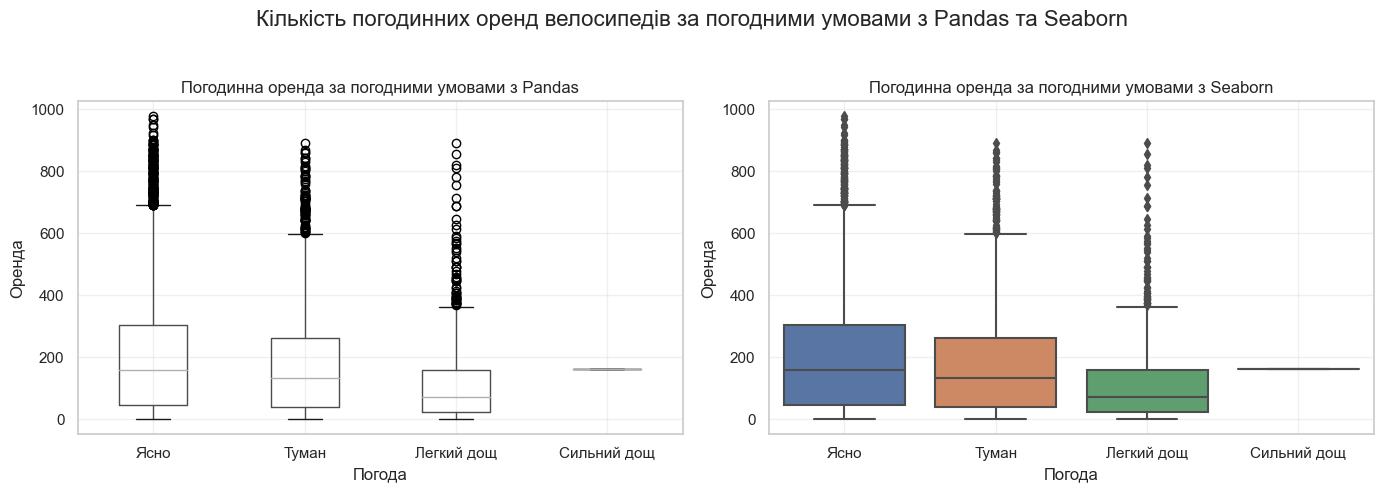

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1 - Pandas box plot
df.boxplot(column="count", by="weather_name", ax=ax[0])

ax[0].set_title("Погодинна оренда за погодними умовами з Pandas")
ax[0].set_xlabel("Погода")
ax[0].set_ylabel("Оренда")
ax[0].grid(True, alpha=0.3)

# 2 - Seaborn box plot
sns.boxplot(data=df, x="weather_name", y="count", ax=ax[1])

ax[1].set_title("Погодинна оренда за погодними умовами з Seaborn")
ax[1].set_xlabel("Погода")
ax[1].set_ylabel("Оренда")
ax[1].grid(True, alpha=0.3)


# Заголовок всієї сітки
fig.suptitle("Кількість погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("boxplot_pandas_vs_seaborn.png", dpi=300, bbox_inches="tight")
plt.show()

Яка візуальна різниця між Pandas та Seaborn бокс-плотами?
як і в попередньому завданні Pandas показує базовий варіант, Seaborn - стилізований, більш читабельний і завершений. В Seaborn чіткіше видно медіану, викиди не забивають картинку жирністю. 

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [13]:
numeric = ["temp", "atemp", "humidity", "windspeed", "casual", "registered", "count"]

In [14]:
corr_matrix = df[numeric].corr()
corr_matrix

,temp,atemp,humidity,windspeed,casual,registered,count
temp,1.000000,0.984948,-0.064949,-0.017852,0.467097,0.318571,0.394454
atemp,0.984948,1.000000,-0.043536,-0.057473,0.462067,0.314635,0.389784
humidity,-0.064949,-0.043536,1.000000,-0.318607,-0.348187,-0.265458,-0.317371
windspeed,-0.017852,-0.057473,-0.318607,1.000000,0.092276,0.091052,0.101369
casual,0.467097,0.462067,-0.348187,0.092276,1.000000,0.497250,0.690414
registered,0.318571,0.314635,-0.265458,0.091052,0.497250,1.000000,0.970948
count,0.394454,0.389784,-0.317371,0.101369,0.690414,0.970948,1.000000


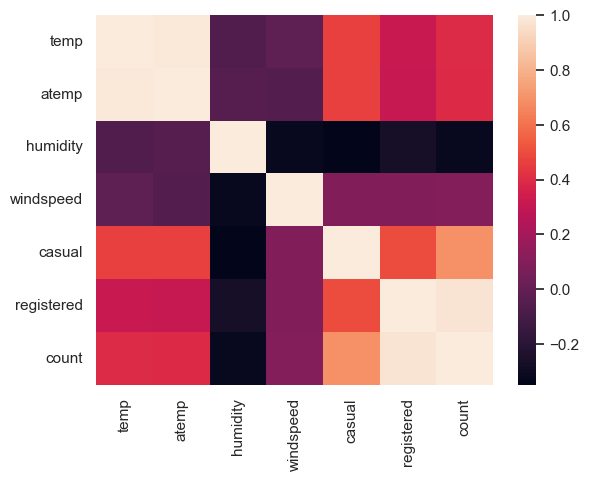

In [15]:
sns.heatmap(corr_matrix);

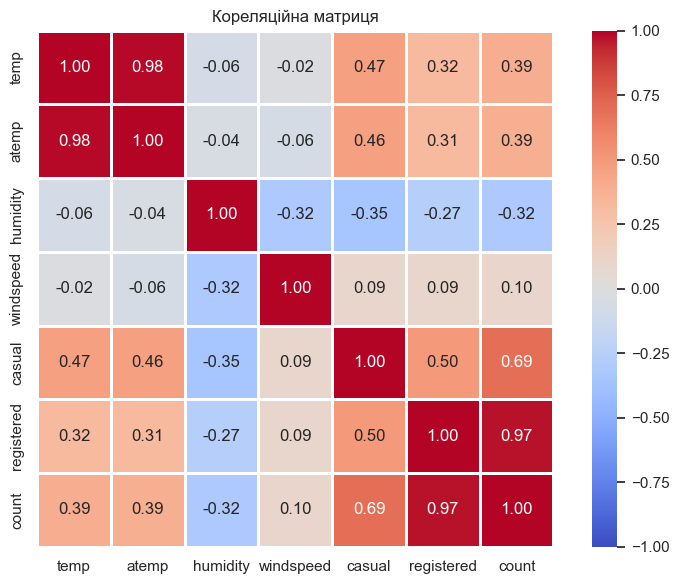

In [16]:
plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,  square=True, linewidths=1)
plt.title("Кореляційна матриця")
plt.tight_layout()

plt.savefig("corr_matrix_seaborn.png", dpi=300, bbox_inches="tight")
plt.show()

Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
найсильніший зв'язок загальної кількості оренд (count) - із дуже сильна позитивна кореляція між count та registered, сильна також із casual, що логічно, оскільки з них і складається показник count. Помірна кореляція  також між count та temp, atemp.

Яка кореляція між temp та atemp? Чому?
Змінні temp та atemp мають дуже високу позитивну кореляцію (0.98), оскільки ці показники майже дублюють один одного.

Які змінні мають негативну кореляцію?
"humidity" має негативну кореляцію з усіма іншими показниками. найбільш вираджену із count, casual, registered - зі зростанням вологості кількість оренд зменшується.
windspeed має дуже слабку кореляцію з count 0.10 та з temp -0.02, тобто це зовсім не суттєвий звязок із з кількістю оренд.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?